In [1]:
cd ..

c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = "distilbert-base-uncased"
# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model)
# Load the model
model = DistilBertModel.from_pretrained(model)

In [4]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [5]:
attraction_df = pd.read_csv("./Data/FinalDataset/Data.csv")
ratings_df = pd.read_csv("./Data/FinalDataset/rating_final.csv")
ratings_df.head()


,user_id,place_id,rating
0,9,4141,5
1,10,4141,5
2,11,4141,5
3,12,4141,5
4,13,4141,4


In [6]:
# Rename the 'id' column to 'place_id'
attraction_df.rename(columns={'id': 'place_id'}, inplace=True)
attraction_df.head()

,place_id,name,description,latitude,longitude,province,location,tags
0,1,Chapat Ganesh Mandir,Chapat Ganesh Temple is Ganesh temple located ...,27.671314,85.328967,Bagmati Province,Bagmati Province,"hindu, temple, pilgrimage"
1,2,Mayadevi Temple,Religious Site The Mayadevi temple is situated...,27.469641,83.275785,Lumbini Province,Lumbini Province,"buddhist, pilgrimage"
2,3,Sikali Mandir,Religious Site Sikali Temple lies in the south...,27.643535,85.285502,Bagmati Province,Kathmandu Valley,"hindu, temple, cultural"
3,4,Bala Guru Sadananda,Bala Guru Sadananda's shrine at his Ashram in ...,27.357001,87.137018,Koshi Province,Shadananda Municipality,"historical, monument"
4,5,21st Century Art Gallery,"21st Century Art Gallery, located in Kathmandu...",27.715548,85.309497,Bagmati Province,Kathmandu,"art_gallery, museum, cultural"


In [7]:
# Add a new column 'attractionID'
attraction_df.dropna(subset=['place_id'], inplace=True)


In [8]:
# Ensure all values in place_id are numeric before converting to integers
attraction_df['place_id'] = pd.to_numeric(attraction_df['place_id'], errors='coerce').astype('Int64')

ratings_df1 = ratings_df[ratings_df['place_id'].isin(attraction_df['place_id'])]
ratings_df1.head()

,user_id,place_id,rating
8,17,1132,5
9,18,1132,5
10,19,1132,5
11,20,1132,5
12,21,1132,4


In [9]:
# Check if a GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)

cuda


In [10]:
def generate_embeddings(text):
    # Tokenize the input text and move the input tensors to the device
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        # Pass the inputs through the model
        outputs = model(**inputs)
    
    # Generate embeddings using mean pooling over token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    
    # Optionally move the embeddings back to the CPU
    embeddings = embeddings.cpu().numpy()
    # Debug: Print the shape of the embeddings
    print(f"Generated embeddings shape: {embeddings.shape}")

    return embeddings

                        

In [11]:
# Fill null values in the 'description' column with an empty string
attraction_df['description'] = attraction_df['description'].fillna('')

# Apply the generate_embeddings function to the 'description' column
attraction_df['Embeddings'] = attraction_df['description'].apply(generate_embeddings)


Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings

In [12]:
def custom_cosine_similarity(vector_a, vector_b):
    # Ensure the vectors are numpy arrays
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)
    
    # Calculate the dot product and magnitudes
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    
    # Avoid division by zero
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    
    # Compute cosine similarity
    similarity = dot_product / (magnitude_a * magnitude_b)
    return similarity

In [13]:
attraction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   place_id     1862 non-null   Int64  
 1   name         1862 non-null   object 
 2   description  1862 non-null   object 
 3   latitude     1862 non-null   float64
 4   longitude    1862 non-null   float64
 5   province     1862 non-null   object 
 6   location     1862 non-null   object 
 7   tags         1862 non-null   object 
 8   Embeddings   1862 non-null   object 
dtypes: Int64(1), float64(2), object(6)
memory usage: 132.9+ KB


In [14]:
# 2. User Profile Construction
def build_user_profile(user_id):
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    high_rated_places = user_ratings[user_ratings['rating'] >= 4]
    if high_rated_places.empty:
        return None
    
    # Convert embeddings to NumPy arrays
    place_embeddings = np.array(attraction_df[attraction_df['place_id'].isin(high_rated_places['place_id'])]['Embeddings'].tolist())
    
    # Average the embeddings to form the user profile
    if place_embeddings.size == 0:
        print(f"Error: place_embeddings is empty for place_id: {high_rated_places['place_id']}")
        # Handle gracefully or provide a default
        user_profile = np.zeros((768,))
    else:
        user_profile = place_embeddings.mean(axis=0)

    user_profile = place_embeddings.mean(axis=0)
    return user_profile


In [15]:
# 3. Recommendation
def recommend_places(user_id, top_n=5):
    user_profile = build_user_profile(user_id)
    # print(user_profile.shape)
    if user_profile is None:
        return pd.DataFrame(columns=['place_id', 'description', 'similarity'])
    # Calculate similarity between user profile and all attraction embeddings
    similarities = cosine_similarity([user_profile], attraction_df['Embeddings'].tolist()).flatten()
    attraction_df['similarity'] = similarities

    # Sort the attractions by similarity and get top_n recommendations
    recommended_places = attraction_df.sort_values(by='similarity', ascending=False).head(top_n)
    
    return recommended_places[['place_id', 'name' ,'description', 'similarity']]


In [16]:
# Drop rows with NaN values in the 'place_id' column
ratings_df.dropna(subset=['place_id'], inplace=True)

# Convert 'place_id' column to integers
ratings_df['place_id'] = ratings_df['place_id'].astype(int)

user_id = 13
recommend_places(user_id,10)

,place_id,name,description,similarity
995,996,Kabristaan Dewanganj Sunsari,"Kabristaan Dewanganj, also known as the Dewang...",1.000000
1595,1596,Petbharwa Math Rautahat Nepal,"Petbharwa Math, located at X5WQ+W6, Sanatapur ...",0.945002
1707,1708,Rahadev Temple,"\r\n\r\nThe Rahadev Temple, situated in Puru, ...",0.943757
309,310,Bogati Thar,"Bogati Thar, located along the Baglung-Beni Ro...",0.941897
1191,1192,Kushaha Bazar Wali Masjid,Kushaha Bazar Wali Masjid is a mosque located ...,0.940331
238,239,Bhelahi Bazar,"Bhelahi Bazar, situated in Madhav Narayan-3, B...",0.940039
952,953,J.P Vetwal Smriti Park,J.P Vetwal Smriti Park is a commemorative park...,0.938518
1677,1678,Pokhari (Bhaimashwor Pokhari),"\r\n\r\nPokhari Pokhari, also known as Bhaimas...",0.938065
241,242,Bhim Sakhuwa,"\r\n\r\nBhim Sakhuwa, located at 45QF+9MQ in K...",0.937823
76,77,Anutha Mahato Memorial Trust,"The Anutha Mahato Memorial Trust, located at R...",0.936839


In [17]:
print(attraction_df['Embeddings'].head())


0    [-0.057272054, 0.108186506, 0.04837382, -0.061...
1    [-0.13549657, 0.07388258, -0.06519881, -0.2147...
2    [-0.1111075, 0.12172582, -0.011140166, -0.2895...
3    [0.106655024, 0.1835627, -0.15536307, -0.37485...
4    [-0.0665003, 0.14401945, 0.30438823, -0.054342...
Name: Embeddings, dtype: object


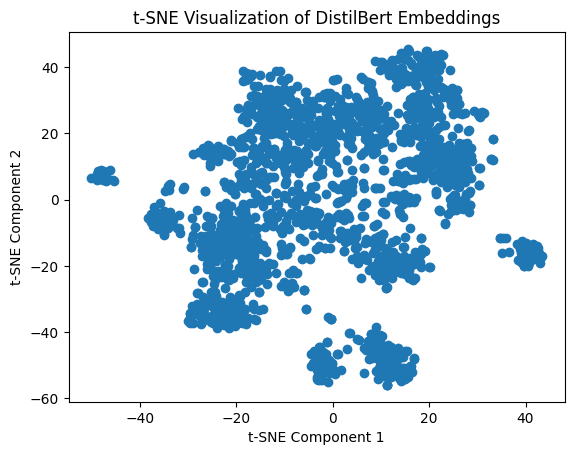

In [18]:

def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])


Average Hit Rate: 0.9841269841269841
Average NDCG: 0.991366545191353
Average RMSE: 0.02420235714978642


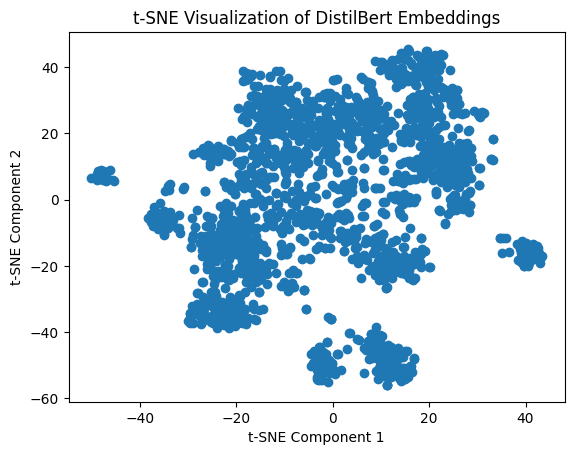

In [19]:

# Define relevance threshold
RELEVANCE_THRESHOLD = 4

# Hit Rate at K
def hit_rate_at_k(recommended_places, relevant_places, k):
    recommended_set = set(recommended_places[:k])
    relevant_set = set(relevant_places)
    return 1 if any(item in recommended_set for item in relevant_set) else 0

# NDCG at K
def ndcg_at_k(recommended_places, relevant_places, k):
    recommended_set = set(recommended_places[:k])
    relevant_set = set(relevant_places)
    
    dcg = 0.0
    idcg = 1.0
    
    for idx, item in enumerate(recommended_places[:k]):
       if item in relevant_set:
           dcg += 1.0 / np.log2(idx + 2)

    return dcg / idcg if relevant_set else 0.0
  
# Function to compute RMSE
def rmse(recommended_place_ids, relevant_place_ids, ratings):
    """Calculates RMSE between predicted and actual ratings."""
    
    if not relevant_place_ids:
        return 0.0 # Return 0 if there is nothing to calculate
    
    # Ensure relevant_place_ids is a set
    relevant_set = set(relevant_place_ids)
    
    # Fetch actual ratings for the relevant places, using the place_id from recommendations
    actual_ratings = ratings_df1[(ratings_df1['place_id'].isin(relevant_set)) & (ratings_df1['user_id'] == user_id)]['rating'].values
    
    # Get predicted ratings (as similarity), using the place_id from recommendations
    predicted_ratings = np.array(attraction_df[attraction_df['place_id'].isin(recommended_place_ids)]['similarity'].values)[:len(actual_ratings)]

    
    # If there aren't predicted ratings for all actual ratings, skip and return 0.0
    if not actual_ratings.size == len(predicted_ratings):
       return 0.0
    
    if not actual_ratings.size:
      return 0.0


    squared_errors = (np.array(predicted_ratings) - np.array(actual_ratings)) ** 2
    rmse_value = np.sqrt(np.mean(squared_errors))

    return rmse_value

# Evaluate for a single user
def evaluate_user(user_id, k=5):
    test_user_ratings = ratings_df1[ratings_df1['user_id'] == user_id]
    relevant_places = test_user_ratings[test_user_ratings['rating'] >= RELEVANCE_THRESHOLD]['place_id'].tolist()
    
    if not relevant_places:
        return None  # No relevant places to evaluate
    
    recommendations = recommend_places(user_id, top_n=k)['place_id'].tolist()
    
    hit_rate = hit_rate_at_k(recommendations, relevant_places, k) if recommendations else 0.0
    ndcg = ndcg_at_k(recommendations, relevant_places, k) if recommendations else 0.0
    rmse_value = rmse(recommendations, relevant_places, test_user_ratings['rating'].values) if recommendations else 0.0

    return {'hit_rate': hit_rate, 'ndcg': ndcg, 'rmse':rmse_value}


# Evaluate for all users
def evaluate_system(k=5):
    users = ratings_df1['user_id'].unique()
    metrics = {'hit_rate': [], 'ndcg': [], 'rmse': []}
    
    for user_id in users:
        user_metrics = evaluate_user(user_id, k)
        if user_metrics:
            metrics['hit_rate'].append(user_metrics['hit_rate'])
            metrics['ndcg'].append(user_metrics['ndcg'])
            metrics['rmse'].append(user_metrics['rmse'])
    
    avg_hit_rate = np.mean(metrics['hit_rate']) if metrics['hit_rate'] else 0.0
    avg_ndcg = np.mean(metrics['ndcg']) if metrics['ndcg'] else 0.0
    avg_rmse = np.mean(metrics['rmse']) if metrics['rmse'] else 0.0
    
    return {'avg_hit_rate': avg_hit_rate, 'avg_ndcg': avg_ndcg, 'avg_rmse':avg_rmse}


# Ensure embeddings do not contain NaN values
attraction_df['Embeddings'] = attraction_df['Embeddings'].apply(lambda x: np.nan_to_num(x))

# Calculate metrics
results = evaluate_system(k=5)
print("Average Hit Rate:", results['avg_hit_rate'])
print("Average NDCG:", results['avg_ndcg'])
print("Average RMSE:", results['avg_rmse'])


def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])

In [20]:
print(attraction_df['Embeddings'].isna().sum())
print(attraction_df['Embeddings'].apply(lambda x: np.array(x).shape).unique())


0
[(768,)]
